# 1 - Handwritten Digit Recognition - Computer Vision

<img src='https://www.xavor.com/wp-content/uploads/2022/10/Overview-of-Computer-Vision.jpg'>

Bu çalışmada el yazısıyla yazılmış rakam görsellerini tanıyan bir computer vision modeli geliştireceğim. Bu proje özellikle görüntü sınıflandırma mantığını anlamak ve CNN kullanmak için uygun bir örnektir.

## Akış

1. Veriyi yükleme
2. Veriyi okuma ve inceleme
3. Veri temizleme
4. Feature engineering
5. CNN modeli kurma
6. Modeli eğitme
7. Modeli değerlendirme
8. Örnek tahmin
9. Sonuç

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

## 1. Veriyi Yükleme

In [2]:
# Bu projede Kaggle'dan indirilen MNIST datasetini Colab üzerinden zip dosyası olarak açıp kullanacağım.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
zip_path = '/content/drive/MyDrive/Colab Data Dosyaları/MNIST Handwritten Digits.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

os.listdir('/content')[:20]

['.config', 'mnist_train.csv', 'mnist_test.csv', 'drive', 'sample_data']

## 2. Veriyi Okuma ve İnceleme

In [5]:
# Bu bölümde train ve test csv dosyalarını okuyup veri yapısını inceleyeceğim.

In [6]:
train_path = '/content/mnist_train.csv'
test_path = '/content/mnist_test.csv'

train_df = pd.read_csv(train_path, low_memory=False)
test_df = pd.read_csv(test_path, low_memory=False)

train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
1,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
train_df.shape, test_df.shape

((60001, 785), (10001, 785))

In [8]:
train_df.columns.tolist()[:10]

['label',
 'pixel1',
 'pixel2',
 'pixel3',
 'pixel4',
 'pixel5',
 'pixel6',
 'pixel7',
 'pixel8',
 'pixel9']

## 3. Veri Temizleme

In [9]:
# Bu bölümde tekrar eden başlık satırı varsa temizleyip tüm verileri sayısal hale getireceğim.

In [10]:
if str(train_df.iloc[0, 0]).lower() == 'label':
    train_df = train_df.iloc[1:].reset_index(drop=True)

if str(test_df.iloc[0, 0]).lower() == 'label':
    test_df = test_df.iloc[1:].reset_index(drop=True)

train_df = train_df.apply(pd.to_numeric)
test_df = test_df.apply(pd.to_numeric)

train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 4. Feature Engineering

In [11]:
# Bu bölümde piksel değerlerini normalize edeceğim, görüntü boyutuna çevireceğim ve etiketleri one-hot hale getireceğim.

In [12]:
x_train = train_df.drop('label', axis=1).values / 255.0
y_train = train_df['label'].values

x_test = test_df.drop('label', axis=1).values / 255.0
y_test = test_df['label'].values

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

x_train.shape, x_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

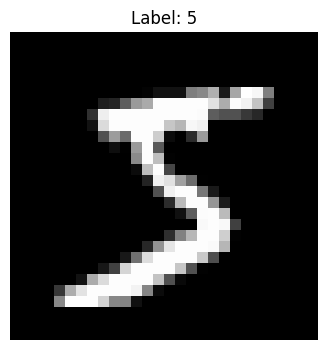

In [13]:
plt.figure(figsize=(4,4))
plt.imshow(x_train[0].reshape(28,28), cmap='gray')
plt.title(f'Label: {y_train[0]}')
plt.axis('off')
plt.show()

## 5. CNN Modeli Kurma

In [14]:
# Bu bölümde el yazısı rakamları tanımak için bir CNN modeli kuracağım.

In [15]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Modeli Eğitme

In [16]:
# Bu bölümde CNN modelini eğitim verisi ile eğiteceğim.

In [17]:
history = model.fit(
    x_train, y_train_cat,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 57s 127ms/step - accuracy: 0.9218 - loss: 0.2589 - val_accuracy: 0.9817 - val_loss: 0.0592
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 47s 112ms/step - accuracy: 0.9781 - loss: 0.0722 - val_accuracy: 0.9857 - val_loss: 0.0507
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 47s 111ms/step - accuracy: 0.9846 - loss: 0.0505 - val_accuracy: 0.9898 - val_loss: 0.0377
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 47s 110ms/step - accuracy: 0.9876 - loss: 0.0405 - val_accuracy: 0.9897 - val_loss: 0.0340
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 47s 111ms/step - accuracy: 0.9899 - loss: 0.0327 - val_accuracy: 0.9893 - val_loss: 0.0345


## 7. Modeli Değerlendirme

In [18]:
# Bu bölümde modeli test verisi üzerinde değerlendirip accuracy sonucuna bakacağım.

In [19]:
test_loss, test_accuracy = model.evaluate(x_test, y_test_cat, verbose=0)
print('Test Accuracy:', test_accuracy)
print('Test Loss:', test_loss)

Test Accuracy: 0.9919000267982483
Test Loss: 0.0276165958493948


In [20]:
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.98      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       1.00      0.98      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



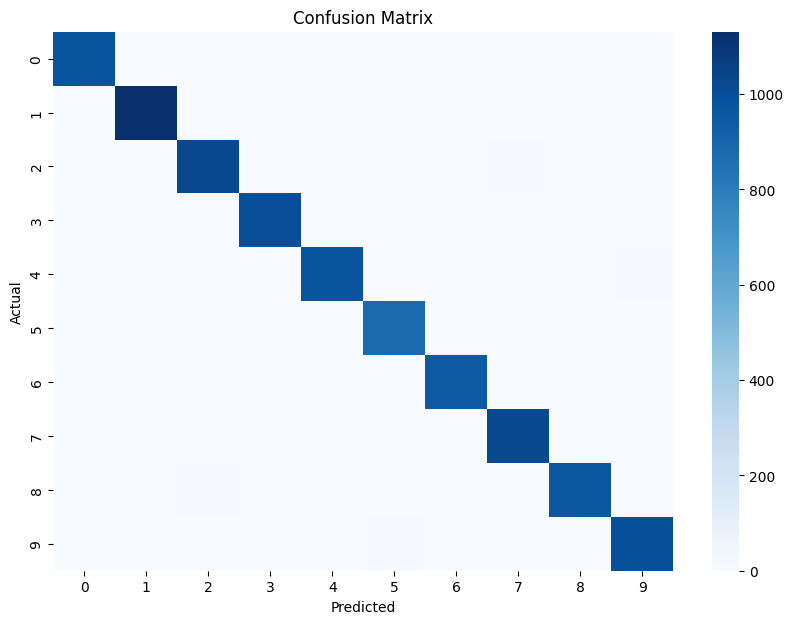

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 8. Örnek Tahmin

In [22]:
# Bu bölümde test setinden bir örnek rakam için tahmin yapacağım.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


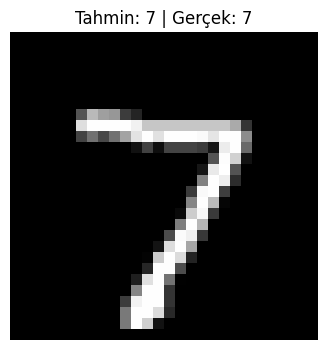

In [23]:
sample_index = 0
sample_image = x_test[sample_index]
sample_prediction = np.argmax(model.predict(sample_image.reshape(1,28,28,1)), axis=1)[0]

plt.figure(figsize=(4,4))
plt.imshow(sample_image.reshape(28,28), cmap='gray')
plt.title(f'Tahmin: {sample_prediction} | Gerçek: {y_test[sample_index]}')
plt.axis('off')
plt.show()

## 9. Sonuç

Bu projede el yazısı rakamları tanımak için CNN tabanlı bir computer vision modeli kullanıldı. Elde edilen sonuçlara göre model 0.9919 accuracy değeri elde etti.